In [1]:
import jax.numpy as jnp
import jax as jax
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter


#### Jacobian Matrices For This Construction

System of Equations

$$ \begin{matrix}x(t+1) = x(t) + ucos(\theta) + \alpha v_1(t)  \\ y(t+1) = y(t) + usin(\theta) + \alpha v_2(t) \\ \theta (t+1) = \theta (t) + \omega + \alpha v_3(t)\end{matrix}$$

Analytical Derivation

$$\frac{\partial f(x)}{\partial x} = \begin{bmatrix} 1 & 0 & -usin(\theta) \\ 0 & 1 & ucos(\theta) \\ 0 & 0 & 1 \end{bmatrix}$$

$$ \frac{\partial h(x)}{\partial x} = \begin{bmatrix} (x-1)[(x-1)^2 + y^2]^{-1/2} & y[(x-1)^2 + y^2] & 0 \\ (x+1)[(x+1)^2 + y^2]^{-1/2} & y[(x+1)^2 + y^2] & 0 \end{bmatrix} $$

### Creating Predictor and Corrector classes for filtering
these manage the actual calculation and modeling of the system.

IMPROVEMENTS:
- Separate the dynamics model, or create a filter-method agnostic model
- Decouple physics to another object for modularity
- Find a way to pass alpha on instantiation

In [2]:
class EKF_predictor:
	"""This class is a predictor with a dynamics model from which the estimator will derive a prediction step.
	Fields:
		__last_estimate					- previous estimate
		__last_covariance				- previous covariance
		__predicted_estimate			- current estimate
		__predicted_covariance 			- current covariance
	Methods:
		get_prediction() 				- Calculates a prediction for the next time step
		set_this_covariance()			- Sets the previous/current covariance
		set_this_state()				- Sets the previous/current state
		set_this_control()				- Sets the previous/current control
		__set_predicted_covariance()	- Sets the predicted covariance		
		__get_covariance()				- Calculates teh covariance
		__get_estimate()				- Method representing dynamics of the system
	"""

	__last_state: jnp.ndarray
	__last_control: jnp.ndarray
	__last_covariance: jnp.ndarray
	__predicted_estimate: jnp.ndarray
	__predicted_covariance: jnp.ndarray
	
	def __init__(self, state, control):
		# Initialization
		self.__last_state = state
		self.__last_control = control
		self.__predicted_estimate = None
		self.__predicted_covariance = None
		self.__last_covariance = jnp.eye(state.shape[0])		# safeguard incase covariance is not set
	
	def set_this_covariance(self, covariance): self.__last_covariance = covariance
	def set_this_state(self, state): self.__last_state = state
	def set_this_control(self, control): self.__last_control = control

	@staticmethod
	def __get_estimate(state, control):
		""" uses system dynamics to calculate next step
		Params:
			state 				- current state
			control 			- control input
		Returns:
			None
		"""
		theta = state[2, 0]
		u = control[0, 0]
		omega = control[1, 0]

		predicted_state = (state 
				+ jnp.array([[u*jnp.cos(theta)], 
				 			[u*jnp.sin(theta)], 
				 			[omega]]) 
				)
		return predicted_state
		 
	def __set_predicted_covariance(self):
		""" calculates the covariance matrix and sets new covariance to __predcited_covariance
		Params:
			estimate 					- current estimate value
			covariance 					- current covariance value
			Q  							- process uncertainty
		Returns:
			None
		"""
		alpha = 0.03 #HARDCODED NEEDS TO BE PASSED AS A PARAMETER IN FUTURE UPDATE
		F = jax.jacfwd(self.__get_estimate, argnums=0)(self.__last_state, self.__last_control).squeeze()
		Q = alpha * jnp.eye(F.shape[0])
		self.__predicted_covariance = F @ self.__last_covariance @ F.T + Q


	def get_prediction(self):
		self.__predicted_estimate = self.__get_estimate(self.__last_state, self.__last_control)
		self.__set_predicted_covariance() 
		return self.__predicted_estimate, self.__predicted_covariance
	

In [3]:
class EKF_corrector:
	"""This class is a corrector for predicted filter value.
	Fields:
		__predicted_estimate			- predicted estimated value
		__predcited_covariance			- predicted covariance value
		__observation					- observation values
		__filtered_estimate				- new estimate value
		__filtered_covariance 			- new covariance value
	Methods:
		get_filtered_values() 			- Calculates a prediction and estimate for the next time step
		set_observation()				- Sets observation value
		__set_filtered_covariance()	- Sets the previous/current covariance		
		__set_filtered_estimate()		- Calculates the covariance
		__get_filtered_covariance()		- Calculates the filtered covariance
	"""
	
	__predicted_estimate: jnp.ndarray
	__predicted_covariance: jnp.ndarray
	__observation: jnp.ndarray
	__filtered_estimate: jnp.ndarray
	__filtered_covariance: jnp.ndarray
	
	def __init__(self, predicted_estimate, predicted_covariance):
		# Initialization
		self.__predicted_estimate = predicted_estimate
		self.__predicted_covariance = predicted_covariance
		self.__filtered_estimate = None
		self.__filtered_covariance = None
	
	def set_observation(self, observation): self.__observation = observation

	@staticmethod
	def __get_h(state):
		""" Calculate the observation model for filtered update
		Params:
			state 					- current, predicted state
		Returns:
			new_obseration_model 	- New observation model
		"""
		x = state[0, 0]
		y = state[1, 0]
		y1_expected = jnp.sqrt((x-1)**2 + y**2)
		y2_expected = jnp.sqrt((x+1)**2 + y**2)
		new_observation_model = jnp.array([[y1_expected],
											[y2_expected]]
											)
		return new_observation_model

	def __set_filtered_values(self):
		""" uses observation model to calculate filtered covariance
		Params:
			state 				- current state
		Returns:
			None
		"""
		beta = 0.5 #HARDCODED NEEDS TO BE PASSED AS A PARAMETER IN FUTURE UPDATE
		H = jax.jacfwd(self.__get_h, argnums=0)(self.__predicted_estimate).squeeze()
		R = beta * jnp.eye(H.shape[0])
		S = H @ self.__predicted_covariance @ H.T + R
		K = self.__predicted_covariance @ H.T @ jnp.linalg.inv(S)

		self.__filtered_covariance = self.__predicted_covariance - self.__predicted_covariance @ H.T @ jnp.linalg.inv(S) @ H @ self.__predicted_covariance
		self.__filtered_estimate = self.__predicted_estimate + K @ (self.__observation - self.__get_h(self.__predicted_estimate))


	def get_filtered_values(self):
		self.__set_filtered_values()
		return self.__filtered_estimate, self.__filtered_covariance
	

## Extended Kalman Filter Class
This extended kalman filter class is formated for easy translation into C++ in future updates.

### TO IMPROVE
- Heartbeat speed should be defined at a system level
- Sensor limits should be based on hardware datasheets
- Add consideration for reference/value separation and shared memory access.

In [4]:
# Generating an EKF class for easy transition to C++
class EKF_Estimation_Filter:
    """Extended Kalman Filter Class
    Fields:
        Private __measurement               - current measurement
        Private __initial_state             - initial state
        Private __predictor                 - prediction class for the filter
        Private __corrector                 - corrector class for the filter
        Private __covariance                - Current covariance
        Private __observation_dim           - Dimension of the observation model
        Private __state_dim                 - Dimension of the state space
        Private __estimate                  - Current state estimate
        Private __control                   - Current control
        Private __observation               - Current observation
    Constants:
        Private __HEARTBEAT_SPEED           - Universal synchronized timing
        Private __SENSOR_LIMITS             - Saturation points for the sensor
    Methods:
        Public __init__()                   - Constructor for class
        Public get_predictor()              - returns predictor object
        Public get_corrector()              - returns corrector object
        Public get_covariance()             - returns the current covariance calculation
        Public get_estimate()               - returns the current prediction type
        Public set_initial_covariance()     - Sets the initial covariance for the filter
        Public set_initial_estimate()       - Sets the initial estimate state vector
        Public step()                       - Creates a public function to iterate the filter
    """
    
    # Fields 
    __buffer_reference: jnp.ndarray
    __writing_index: int
    __predictor: object
    __corrector: object
    __covariance: jnp.ndarray
    __observation_dim: int
    __state_dim: int
    __estimate: jnp.ndarray
    __control: jnp.ndarray
    __observation: jnp.ndarray
    
    def __init__(self, state_dim, observation_dim, initial_state):
        """Class Constructor:
        Params:
            state_dim           - saves the dimension of the state
            observation_dim     - saves the dimension of the observation
            initial_state       - the true initial matrix state guess
        Returns:
            Constructed Class EKF_Estimation_filter"""
        
        # Instantiating values
        self.__state_dim = state_dim
        self.__observation_dim = observation_dim

        # Defining state space and initial structural assumptions
        self.__estimate = initial_state
        self.__covariance = jnp.eye(self.__state_dim)
        self.__control = jnp.zeros((2, 1)) # Guard-band initialization for control vector dim

        # Allocating memory and enforcing encapsulation
        self.__buffer_reference = None
        self.__writing_index = None
        
        # FIXED: Delayed predictor/corrector object instantiation to step() loop 
        # to ensure control inputs and observations are alive before being processed.
        self.__predictor = None
        self.__corrector = None
    
    # Standard Encapsulation
    def get_predictor(self): return self.__predictor
    def get_corrector(self): return self.__corrector
    def get_covariance(self): return self.__covariance
    def get_estimate(self): return self.__estimate

    def set_initial_covariance(self, uncertainty):
        """ Sets initial covariance.
        Params:
            uncertainty - initial uncertainty guess scalar or matrix
        """
        self.__covariance = self.__covariance * uncertainty
    
    def set_initial_estimate(self, initial_vector):
        """ Sets initial estimate.
        Params:
            initial_vector - initial guess for estimate
        """
        self.__estimate = initial_vector

    def step(self, observation, control):
        """ Creates a public function to iterate the filter through one timestep
        Params:
            observation - Current sensor frame array 
            control     - Current command array 
        Returns:
            Current filter state estimate and error covariance matrices
        """
        # Pull in observation/control and update object internal fields
        self.__observation = observation
        self.__control = control
        
        # 1. Prediction Lifecycle Stage
        if self.__predictor is None:
            # First frame instance instantiation
            self.__predictor = EKF_predictor(self.__estimate, self.__control)
        else:
            # Updating pointers/values on existing sub-component class memory spaces
            self.__predictor.set_this_state(self.__estimate)
            self.__predictor.set_this_control(self.__control)
            
        self.__predictor.set_this_covariance(self.__covariance)
        pred_estimate, pred_covariance = self.__predictor.get_prediction()

        # 2. Correction Lifecycle Stage
        if self.__corrector is None:
            self.__corrector = EKF_corrector(pred_estimate, pred_covariance)
        else:
            # Re-instantiate or explicitly update the correction step boundaries 
            # with the freshly transformed a priori state estimation data
            self.__corrector = EKF_corrector(pred_estimate, pred_covariance)
            
        self.__corrector.set_observation(self.__observation)
        
        # Pull down finalized, filtered post-update transformations
        self.__estimate, self.__covariance = self.__corrector.get_filtered_values()

        return self.__estimate, self.__covariance

### Data Handling
Data will be passed into a 'ring' memory function to replicate on-the-fly creation.

main will execute the following sequence: Update memory, call the estimator, Save the output.

All calls will be "by reference" to prevent data contamination from other protocols (consumer / producer model)


In [5]:
# Simulating main loop and sensor readings
if __name__ == "__main__":
    # Declaring values for analysis
    SENSOR_MEMORY_MAX = 10                          # Constant to define max size of ring buffer
    HISTORY_MEMORY_MAX = 200                       # Constant to define size of history buffer
    state_dim = 3                                   # variable describing the size of the state space
    observation_dim = 2                             # variable describing the size of the observation space

    # Define the specific assignment control inputs (u = 0.1, omega = 0.02)
    current_control = jnp.array([[0.1], [0.02]])
    
    # Define an initial guess for state vector space (starting at the origin)
    initial_state_guess = jnp.array([[0.0], [0.0], [0.0]])

    # Instantiate the top-level master filter coordinator instance
    filter_obj = EKF_Estimation_Filter(state_dim, observation_dim, initial_state_guess)
                    
    # Initialize buffers to accommodate multi-dimensional tracking shapes
    sensor_readings_ring = jnp.zeros((SENSOR_MEMORY_MAX, observation_dim, 1))  # 2D observation ring buffer
    writing_index = 0                               # index for position in buffer
    history_index = 0                               # index for history position
    
    # Allocating full state sub-arrays to preserve array layout dimensions
    history_log = jnp.zeros((HISTORY_MEMORY_MAX, state_dim, 1)) 
    covariance_log = jnp.zeros((HISTORY_MEMORY_MAX, state_dim, state_dim))

    # --- Data Import Stage ---
    # Loads dataset file 'HW6-Y.txt' directly into the filter loop
    raw_data = np.loadtxt('HW6-Y.txt')
    data_list = [jnp.array([[row[0]], [row[1]]]) for row in raw_data]

    # --- Main Sequential Ring Iteration ---
    for i in range(len(data_list)):
        # Capture incoming observation frame and save it into the ring buffer
        sensor_readings_ring = sensor_readings_ring.at[writing_index].set(data_list[i])
        current_observation = sensor_readings_ring[writing_index]
        
        # Feed active tracking vectors into the EKF step algorithm
        new_estimate, new_covariance = filter_obj.step(current_observation, current_control)
        
        #  Log results to the multi-dimensional history archive via explicit index updates
        history_log = history_log.at[history_index].set(new_estimate)
        covariance_log = covariance_log.at[history_index].set(new_covariance)

        # --- Manage Ring Pointer Indices Safely ---
        writing_index += 1
        if writing_index >= SENSOR_MEMORY_MAX:
            writing_index = 0                       # Reset writing index to zero if out of bounds
            
        history_index += 1
        if history_index >= HISTORY_MEMORY_MAX: 
            history_index = 0                       # Reset history index to 0 if out of bounds

    print("--- Extended Kalman Filter execution finished successfully ---")
    print(f"Total Steps Processed: {len(data_list)}")
    print(f"Final Filtered State Vector:\n{history_log[history_index-1]}")

--- Extended Kalman Filter execution finished successfully ---
Total Steps Processed: 200
Final Filtered State Vector:
[[-7.725051 ]
 [-1.2113211]
 [ 5.274222 ]]


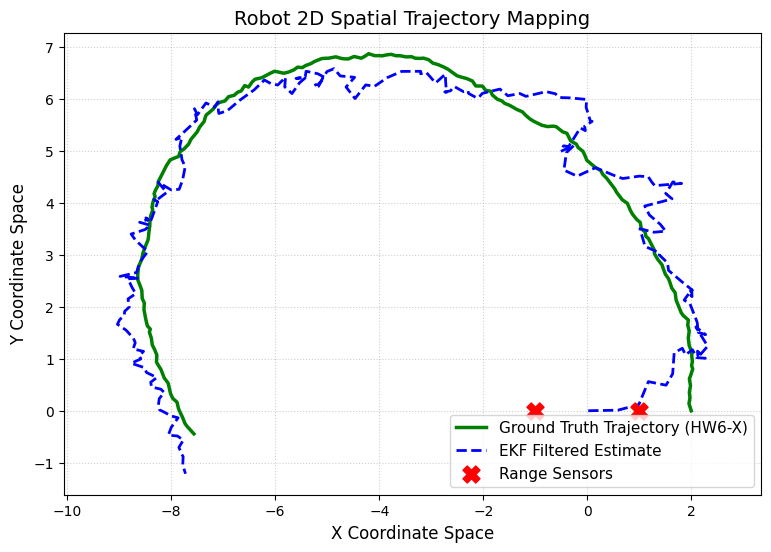

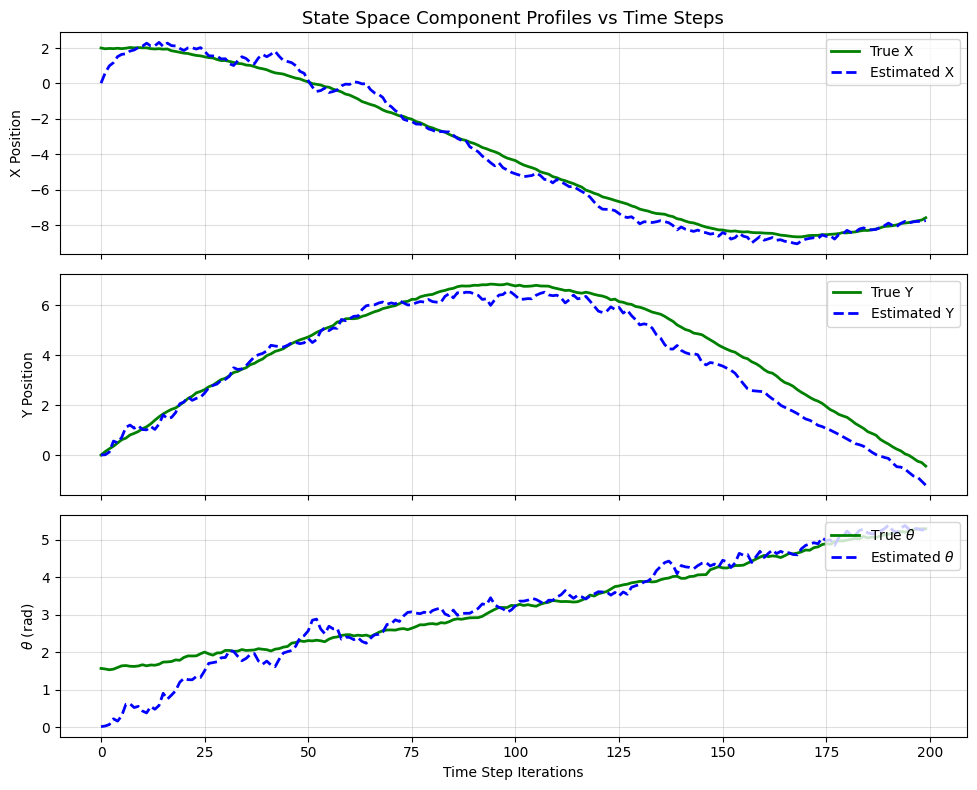

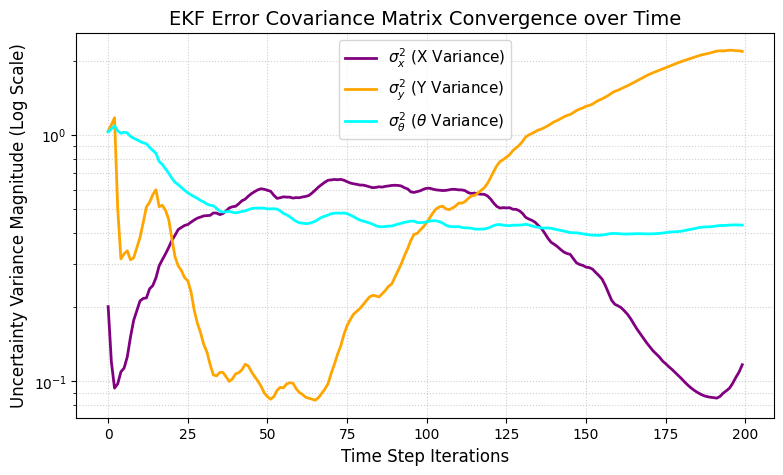

In [6]:
# Total iterations processed
steps_run = len(data_list)

raw_x = np.loadtxt('HW6-X.txt')
raw_y = np.loadtxt('HW6-Y.txt')

# Unpack estimated tracking data from your logged array parameters
x_est = [history_log[t, 0, 0] for t in range(steps_run)]
y_est = [history_log[t, 1, 0] for t in range(steps_run)]
theta_est = [history_log[t, 2, 0] for t in range(steps_run)]

# Extract matching ground truth slices from HW6-X.txt
x_true = raw_x[:steps_run, 0]
y_true = raw_x[:steps_run, 1]
theta_true = raw_x[:steps_run, 2]

# Extract the diagonal values (variance values) from the error covariance logs
var_x = [cov[0, 0] for cov in covariance_log]
var_y = [cov[1, 1] for cov in covariance_log]
var_theta = [cov[2, 2] for cov in covariance_log]

# 2D Position Mapping (Trajectory Comparison)
plt.figure(figsize=(9, 6))
plt.plot(x_true, y_true, label='Ground Truth Trajectory (HW6-X)', color='green', lw=2.5)
plt.plot(x_est, y_est, label='EKF Filtered Estimate', color='blue', linestyle='--', lw=2)
plt.scatter([1, -1], [0, 0], color='red', marker='X', s=150, zorder=5, label='Range Sensors')
plt.title("Robot 2D Spatial Trajectory Mapping", fontsize=14)
plt.xlabel("X Coordinate Space", fontsize=12)
plt.ylabel("Y Coordinate Space", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11)
plt.axis('equal')
plt.show()

# State Tracking Components over Time
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
time_steps = range(steps_run)

axes[0].plot(time_steps, x_true, color='green', lw=2, label='True X')
axes[0].plot(time_steps, x_est, color='blue', linestyle='--', lw=2, label='Estimated X')
axes[0].set_ylabel("X Position")
axes[0].grid(True, alpha=0.4)
axes[0].legend(loc='upper right')
axes[0].set_title("State Space Component Profiles vs Time Steps", fontsize=13)

axes[1].plot(time_steps, y_true, color='green', lw=2, label='True Y')
axes[1].plot(time_steps, y_est, color='blue', linestyle='--', lw=2, label='Estimated Y')
axes[1].set_ylabel("Y Position")
axes[1].grid(True, alpha=0.4)
axes[1].legend(loc='upper right')

axes[2].plot(time_steps, theta_true, color='green', lw=2, label='True $\\theta$')
axes[2].plot(time_steps, theta_est, color='blue', linestyle='--', lw=2, label='Estimated $\\theta$')
axes[2].set_ylabel("$\\theta$ (rad)")
axes[2].set_xlabel("Time Step Iterations")
axes[2].grid(True, alpha=0.4)
axes[2].legend(loc='upper right')
plt.tight_layout()
plt.show()

# Covariance Matrix Convergence
plt.figure(figsize=(9, 5))
plt.plot(time_steps, var_x, label='$\\sigma^2_x$ (X Variance)', color='purple', lw=2)
plt.plot(time_steps, var_y, label='$\\sigma^2_y$ (Y Variance)', color='orange', lw=2)
plt.plot(time_steps, var_theta, label='$\\sigma^2_\\theta$ ($\\theta$ Variance)', color='cyan', lw=2)
plt.title("EKF Error Covariance Matrix Convergence over Time", fontsize=14)
plt.xlabel("Time Step Iterations", fontsize=12)
plt.ylabel("Uncertainty Variance Magnitude (Log Scale)", fontsize=12)
plt.yscale('log')  # Log scale allows you to see the smooth bounding stabilization clearly
plt.grid(True, which="both", linestyle=':', alpha=0.6)
plt.legend(fontsize=11)
plt.show()

In [7]:

# Initialize the plot canvas and styling
fig, ax = plt.subplots(figsize=(9, 6))

# Plot static anchor landmarks (Sensors positioned at x = 1 and x = -1)
ax.scatter([1, -1], [0, 0], color='red', marker='X', s=150, zorder=5, label='Range Sensors')

# Plot a faint background line of the entire true path for spatial context
ax.plot(raw_x[:, 0], raw_x[:, 1], color='green', alpha=0.15, label='Full Ground Truth Path')

# Define empty placeholder line elements that will grow dynamically frame-by-frame
true_line, = ax.plot([], [], color='green', lw=2.5, label='True Position (HW6-X)')
est_line, = ax.plot([], [], color='blue', linestyle='--', lw=2, label='EKF Estimate')

# Set rigid structural viewport boundaries based on the data boundaries
ax.set_xlim(-10, 3)
ax.set_ylim(-2, 10)
ax.set_title("Real-Time Extended Kalman Filter Trajectory Tracking", fontsize=14)
ax.set_xlabel("X Coordinate Space", fontsize=12)
ax.set_ylabel("Y Coordinate Space", fontsize=12)
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='lower left', fontsize=11)

def update(frame):
    """
    Updates the line data vectors up to the current frame index.
    'frame' maps directly to the active time step 't' in the simulation dataset.
    """
    # Dynamic slicing: plots all coordinates from step 0 up to the current frame
    true_line.set_data(raw_x[:frame, 0], raw_x[:frame, 1])
    est_line.set_data(history_log[:frame, 0, 0], history_log[:frame, 1, 0])
    
    return true_line, est_line

# Total length of frames to generate (matching your data length)
total_frames = len(data_list)

# Construct the animation object
# 'interval=40' means 40 milliseconds per frame (~25 frames per second playback speed)
ani = FuncAnimation(fig, update, frames=total_frames, interval=40, blit=True)

print("Compiling frames and exporting GIF file... Please wait.")

# Initialize the Pillow Writer and save the file
# 'fps=25' matches our 40ms frame interval perfectly
writer = PillowWriter(fps=25)
ani.save('ekf_trajectory.gif', writer=writer)

plt.close(fig) # Closes the static canvas window cleanly
print("Successfully exported 'ekf_trajectory.gif' to your directory!")

Compiling frames and exporting GIF file... Please wait.
Successfully exported 'ekf_trajectory.gif' to your directory!
